# 02c — The optimism gap: how hyperparameter tuning lies to you

**Question.** When you tune Prophet by picking the grid combination with the lowest
cross-validation MAPE, how much of that "win" is real predictive skill versus luck of
fitting the specific CV windows — and how does that self-deception grow as the search
grid gets bigger?

This notebook reads the pre-computed results of the experiment
(`data/processed/optimism_gap_results.csv`) and reproduces the headline figure.
The heavy computation — fitting Prophet across 180 hyperparameter combinations × dozens
of rolling windows — lives in `src/optimism_gap_experiment.py` and was run once locally.

**Why this matters for the project.** Every model in ARICast is selected by CV MAPE.
If tuning systematically flatters the selected model, the reported rankings are inflated.
This experiment quantifies exactly how much, and shows it is not a rounding error.

## Method, in one paragraph

Build one dense grid (`changepoint_prior_scale` × `seasonality_prior_scale` ×
`changepoint_range` = 180 combos). For every (combo × rolling window) fit Prophet once
and cache the MAPE. Then split the windows **in time**: early windows are the *selection*
set, late windows are the *holdout* set. For each grid size N, draw many random sub-grids
of size N, pick the combo with the best **selection** MAPE, and record both its selection
MAPE (optimistic) and its holdout MAPE (honest). The **optimism gap** is
`holdout − selection`, plotted against N. A widening gap is hyperparameter overfitting
growing with the size of the search.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve data dir whether run from repo root or from notebooks/
HERE = Path.cwd()
ROOT = HERE if (HERE / "data").exists() else HERE.parent
DATA = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"

gap = pd.read_csv(DATA / "optimism_gap_results.csv")
gap

,N,selection_MAPE,holdout_MAPE,holdout_std,optimism_gap,series
0,1,8.566,7.365,1.968,-1.201,United States
1,2,6.807,6.673,1.647,-0.134,United States
2,4,5.287,5.762,0.684,0.475,United States
3,8,4.448,5.704,0.458,1.256,United States
4,16,4.015,5.681,0.397,1.666,United States
5,32,3.804,5.775,0.325,1.971,United States
6,64,3.684,5.600,0.358,1.917,United States
7,128,3.560,5.341,0.302,1.781,United States
8,180,3.476,5.159,0.000,1.683,United States
9,1,10.743,12.044,2.180,1.301,California


## The numbers

`selection_MAPE` is what you would *report* if you tuned and tested on the same windows.
`holdout_MAPE` is the honest out-of-sample error of that same tuned model.
`optimism_gap = holdout − selection`.

In [2]:
for series in gap["series"].unique():
    d = gap[gap["series"] == series]
    worst = d.loc[d["optimism_gap"].idxmax()]
    full = d.loc[d["N"].idxmax()]
    print(f"{series}:")
    print(f"  full-grid (N={int(full.N)}): selection {full.selection_MAPE:.2f}%  "
          f"holdout {full.holdout_MAPE:.2f}%  gap {full.optimism_gap:+.2f} pp")
    print(f"  peak gap: {worst.optimism_gap:+.2f} pp at N={int(worst.N)}\n")

United States:
  full-grid (N=180): selection 3.48%  holdout 5.16%  gap +1.68 pp
  peak gap: +1.97 pp at N=32

California:
  full-grid (N=180): selection 4.92%  holdout 7.74%  gap +2.81 pp
  peak gap: +4.56 pp at N=8



## The curve

Selection MAPE (optimistic) falls monotonically as the grid grows — more combos means a
lower minimum, by definition. Holdout MAPE (honest) does **not** keep improving; the gap
between them is the optimism. The shaded band is ±1 holdout std.

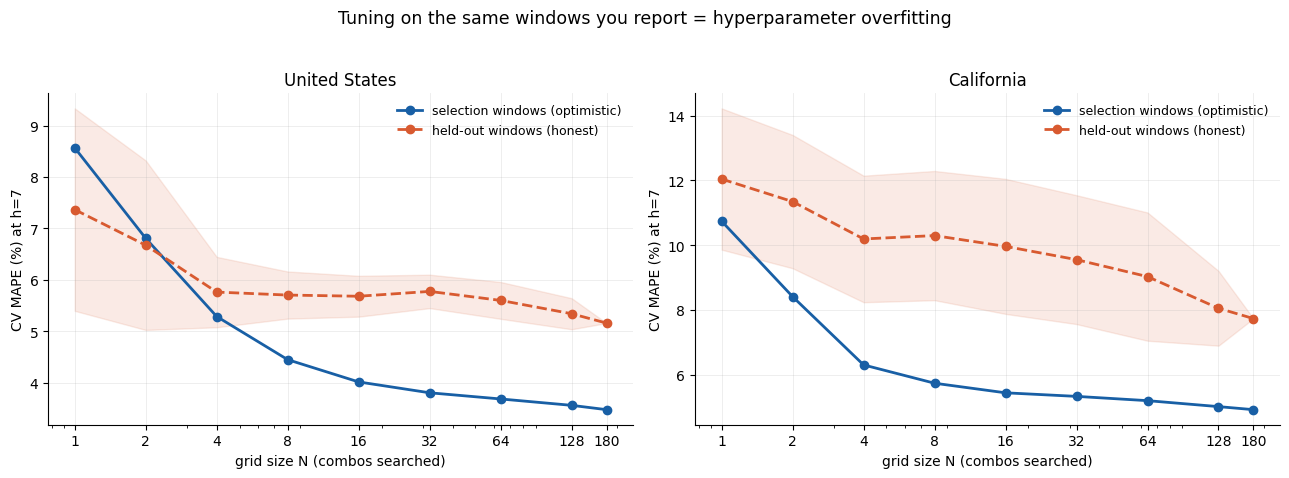

In [3]:
series_list = list(gap["series"].unique())
fig, axes = plt.subplots(1, len(series_list), figsize=(13, 4.6), sharey=False)
if len(series_list) == 1:
    axes = [axes]

for ax, name in zip(axes, series_list):
    d = gap[gap["series"] == name].sort_values("N")
    ax.plot(d.N, d.selection_MAPE, "o-", color="#185FA5", lw=2,
            label="selection windows (optimistic)")
    ax.plot(d.N, d.holdout_MAPE, "o--", color="#D85A30", lw=2,
            label="held-out windows (honest)")
    ax.fill_between(d.N, d.holdout_MAPE - d.holdout_std,
                    d.holdout_MAPE + d.holdout_std, color="#D85A30", alpha=0.12)
    ax.set_xscale("log")
    ax.set_xticks(d.N); ax.set_xticklabels(d.N)
    ax.set_xlabel("grid size N (combos searched)")
    ax.set_ylabel("CV MAPE (%) at h=7")
    ax.set_title(f"{name}", fontsize=12)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Tuning on the same windows you report = hyperparameter overfitting",
             fontsize=12.5, y=1.03)
fig.tight_layout()
plt.show()

## Takeaways

1. **The gap is real and grows with search size.** For California it reaches roughly
   +4.6 pp — i.e. a model that looks like ~5.7% MAPE on selection windows is really
   ~10.3% out of sample. Reporting the selection number would overstate skill by nearly 2×.

2. **United States is less severe but still material** (gap up to ~+2 pp), because its
   series is smoother and less sensitive to changepoint flexibility.

3. **Consequence for ARICast.** This is *why* the project commits to rolling
   cross-validation with a held-out split for every model comparison, and reports holdout
   numbers only. The optimism gap is the quantified cost of the alternative.

The full computation (one-time, parallel over CPU cores) is in
`src/optimism_gap_experiment.py`.